In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [2]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.dropna(inplace=True)

In [5]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
885,0,39.0,29.1250
886,0,27.0,13.0000
887,1,19.0,30.0000
889,1,26.0,30.0000


In [6]:
X_train,X_test,y_train,y_test=train_test_split(df.iloc[:,1:],df.iloc[:,0],test_size=0.2,random_state=False)

In [7]:
kbin_age=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

In [8]:
trf=ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [9]:
X_train_trf=trf.fit_transform(X_train)
X_test_trf=trf.transform(X_test)

In [11]:
trf.named_transformers_['second'].n_bins_


array([10])

In [13]:
trf.named_transformers_['second'].bin_edges_


array([array([  0.    ,   7.7417,   7.8958,   8.6625,  12.35  ,  15.5   ,
               25.9292,  27.9   ,  39.6875,  78.2667, 512.3292])         ],
      dtype=object)

In [14]:
trf.named_transformers_['first'].bin_edges_


array([array([ 0.67, 14.  , 18.  , 22.  , 25.  , 28.  , 31.  , 35.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [15]:
output=pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
    
})

In [16]:
output

,age,age_trf,fare,fare_trf
387,36.0,7.0,13.0000,4.0
685,25.0,4.0,41.5792,8.0
20,35.0,7.0,26.0000,6.0
331,45.5,8.0,28.5000,7.0
396,31.0,6.0,7.8542,1.0
...,...,...,...,...
883,28.0,5.0,10.5000,3.0
238,19.0,2.0,10.5000,3.0
789,46.0,8.0,79.2000,9.0
704,26.0,4.0,7.8542,1.0


In [17]:
X_train_trf

array([[7., 4.],
       [4., 8.],
       [7., 6.],
       ...,
       [8., 9.],
       [4., 1.],
       [8., 9.]], shape=(571, 2))

In [18]:
output['age_labels' ] = pd.cut(x=X_train['Age'],
bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels' ] = pd. cut(x=X_train['Fare'],
bins=trf. named_transformers_['second'].bin_edges_[0].tolist())

In [19]:
output

,age,age_trf,fare,fare_trf,age_labels,fare_labels
387,36.0,7.0,13.0000,4.0,"(35.0, 42.0]","(12.35, 15.5]"
685,25.0,4.0,41.5792,8.0,"(22.0, 25.0]","(39.688, 78.267]"
20,35.0,7.0,26.0000,6.0,"(31.0, 35.0]","(25.929, 27.9]"
331,45.5,8.0,28.5000,7.0,"(42.0, 50.0]","(27.9, 39.688]"
396,31.0,6.0,7.8542,1.0,"(28.0, 31.0]","(7.742, 7.896]"
...,...,...,...,...,...,...
883,28.0,5.0,10.5000,3.0,"(25.0, 28.0]","(8.662, 12.35]"
238,19.0,2.0,10.5000,3.0,"(18.0, 22.0]","(8.662, 12.35]"
789,46.0,8.0,79.2000,9.0,"(42.0, 50.0]","(78.267, 512.329]"
704,26.0,4.0,7.8542,1.0,"(25.0, 28.0]","(7.742, 7.896]"


In [20]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='Count'>

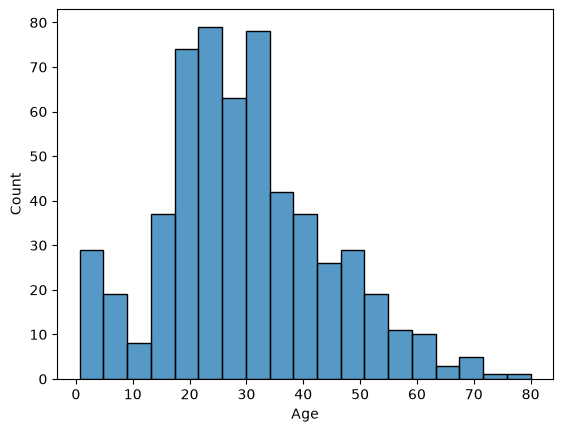

In [23]:
sns.histplot(X_train['Age'])

<Axes: xlabel='age_trf', ylabel='Count'>

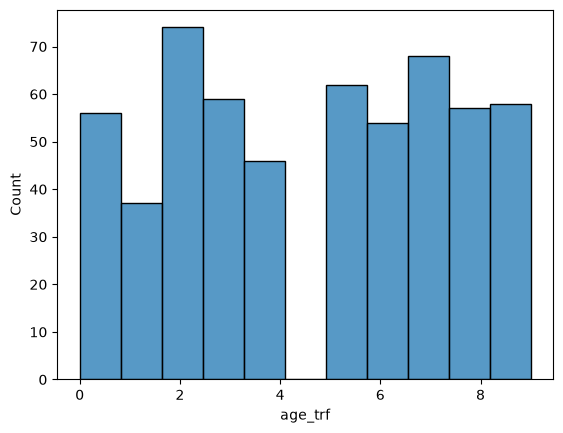

In [30]:
sns.histplot(output['age_trf'])

In [27]:
output

,age,age_trf,fare,fare_trf,age_labels,fare_labels
387,36.0,7.0,13.0000,4.0,"(35.0, 42.0]","(12.35, 15.5]"
685,25.0,4.0,41.5792,8.0,"(22.0, 25.0]","(39.688, 78.267]"
20,35.0,7.0,26.0000,6.0,"(31.0, 35.0]","(25.929, 27.9]"
331,45.5,8.0,28.5000,7.0,"(42.0, 50.0]","(27.9, 39.688]"
396,31.0,6.0,7.8542,1.0,"(28.0, 31.0]","(7.742, 7.896]"
...,...,...,...,...,...,...
883,28.0,5.0,10.5000,3.0,"(25.0, 28.0]","(8.662, 12.35]"
238,19.0,2.0,10.5000,3.0,"(18.0, 22.0]","(8.662, 12.35]"
789,46.0,8.0,79.2000,9.0,"(42.0, 50.0]","(78.267, 512.329]"
704,26.0,4.0,7.8542,1.0,"(25.0, 28.0]","(7.742, 7.896]"
